# Notebook 06 : Analyse des Biais et Grad-CAM

## Objectif
Ce notebook a deux objectifs :

### Partie 1: Grad-CAM
Visualiser ce que le modèle regarde sur les images pour prendre 
ses décisions. Si les zones chaudes correspondent aux lésions d'acné,
cela prouve que le modèle a appris quelque chose de médicalement cohérent.

### Partie 2 — Analyse des biais
Tester le modèle sur des images de peaux foncées pour illustrer 
le problème de représentation dans les datasets d'entraînement.
ACNE04 contient quasi-exclusivement des patients asiatiques — 
notre modèle n'a jamais appris les patterns visuels de l'acné 
sur peaux foncées.

## Contexte
Joy Buolamwini (MIT, 2018) a montré dans son étude "Gender Shades"
que les algorithmes d'IA présentent des écarts de performance 
allant jusqu'à 64 points entre personnes blanches et noires,
uniquement à cause du manque de diversité dans les données d'entraînement.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Chemins
IMAGES_PATH = "../data/images_preprocessees"
TEST_CSV    = "../data/splits/test.csv"
BIAIS_PATH  = "../data/test_biais"

print("Imports ✓")

Imports ✓


In [4]:
# Charger le meilleur modèle:EfficientNet + Cross-Entropy
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

meilleur_modele = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in meilleur_modele.parameters():
    param.requires_grad = False

meilleur_modele.classifier[1] = nn.Linear(
    meilleur_modele.classifier[1].in_features, 4
)

# Charger les poids entraînés
meilleur_modele.load_state_dict(
    torch.load("../results/models/efficientnet_ce_best.pth")
)

meilleur_modele = meilleur_modele.to(device)
meilleur_modele.eval()

print("Modèle EfficientNet + Cross-Entropy chargé ✓")

Modèle EfficientNet + Cross-Entropy chargé ✓


In [5]:
activations = [] 
gradients = []

#on a ici deux listes vides qui vont stocker ce que le réseau calcule pendant le
#foward et le backward

In [8]:
#un hook est un fonction qui s'exécute automatiquement à un moment précis dans le 
#réseau,c'est comme une sorte d'espion dans les couches

#le hook activation s'éxécute pendant le forward pass, il capture ce que la dernière 
#couche de conv produit comme feature
def hook_activation(module, input, output):
    activations.append(output)

#le hook gradient s'exécute pendant le backward pass,il capture les gradients 
#qui passent par cette couche
def hook_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

derniere_conv = meilleur_modele.features[-1] #on cible la dernière couche de convolution d'efficientnet
h1 = derniere_conv.register_forward_hook(hook_activation) #on instale l'espion pour le forward
h2 = derniere_conv.register_full_backward_hook(hook_gradient)#on instale l'espion pour le backward

print("Hooks installés ✓")

Hooks installés ✓


In [9]:
# Charger une image test
IMAGES_PATH = "../data/images_preprocessees"
TEST_CSV = "../data/splits/test.csv"
test = pd.read_csv(TEST_CSV)

# Prendre une image de niveau 2
image_nom = test[test["niveau"] == 2]["image"].iloc[0]
chemin = os.path.join(IMAGES_PATH, image_nom)

# Transformer l'image
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image_pil = Image.open(chemin).convert("RGB")
image_tensor = transform(image_pil)

print(f"Image chargée : {image_nom}")
print(f"Vrai niveau : 2")

Image chargée : levle2_174.jpg
Vrai niveau : 2


In [10]:
# Forward pass — le modèle fait une prédiction
meilleur_modele.eval()
image_input = image_tensor.unsqueeze(0).to(device)
sorties = meilleur_modele(image_input)

# Classe prédite
classe_predite = sorties.argmax().item()
noms = {0: "Pas d'acné", 1: "Légère", 2: "Modérée", 3: "Sévère"}
print(f"Classe prédite : {classe_predite} — {noms[classe_predite]}")

# Backward pass — on calcule les gradients
meilleur_modele.zero_grad()
sorties[0, classe_predite].backward()

print("Gradients calculés ✓")

Classe prédite : 1 — Légère
Gradients calculés ✓


In [11]:
# Récupérer les activations et gradients capturés par les hooks
gradient = gradients[0].squeeze()    # gradients de la dernière conv
activation = activations[0].squeeze() # activations de la dernière conv

print(f"Forme gradient : {gradient.shape}")
print(f"Forme activation : {activation.shape}")

IndexError: list index out of range

In [12]:
# Réinitialiser les listes
activations = []
gradients = []

# Réinstaller les hooks
derniere_conv = meilleur_modele.features[-1]
h1 = derniere_conv.register_forward_hook(hook_activation)
h2 = derniere_conv.register_full_backward_hook(hook_gradient)

# Forward pass — IMPORTANT : pas de torch.no_grad() ici
meilleur_modele.eval()
image_input = image_tensor.unsqueeze(0).to(device)
image_input.requires_grad = True

sorties = meilleur_modele(image_input)
classe_predite = sorties.argmax().item()
print(f"Classe prédite : {classe_predite} — {noms[classe_predite]}")

# Backward pass
meilleur_modele.zero_grad()
sorties[0, classe_predite].backward()

print(f"Activations capturées : {len(activations)}")
print(f"Gradients capturés : {len(gradients)}")

# Supprimer les hooks
h1.remove()
h2.remove()

Classe prédite : 1 — Légère
Activations capturées : 3
Gradients capturés : 3


In [13]:
# Prendre la dernière activation et le dernier gradient
gradient = gradients[-1].squeeze()
activation = activations[-1].squeeze()

print(f"Forme gradient : {gradient.shape}")
print(f"Forme activation : {activation.shape}")

# Calculer les poids — moyenne des gradients par filtre
poids = gradient.mean(dim=(1, 2))

# Calculer la carte de chaleur
carte = torch.zeros(activation.shape[1:])
for i, w in enumerate(poids):
    carte += w * activation[i]

# Garder seulement les valeurs positives
carte = torch.relu(carte)

# Normaliser entre 0 et 1
carte = carte.detach().numpy()
carte = (carte - carte.min()) / (carte.max() - carte.min() + 1e-8)

print(f"Carte de chaleur calculée — forme : {carte.shape}")

Forme gradient : torch.Size([1280, 7, 7])
Forme activation : torch.Size([1280, 7, 7])
Carte de chaleur calculée — forme : (7, 7)


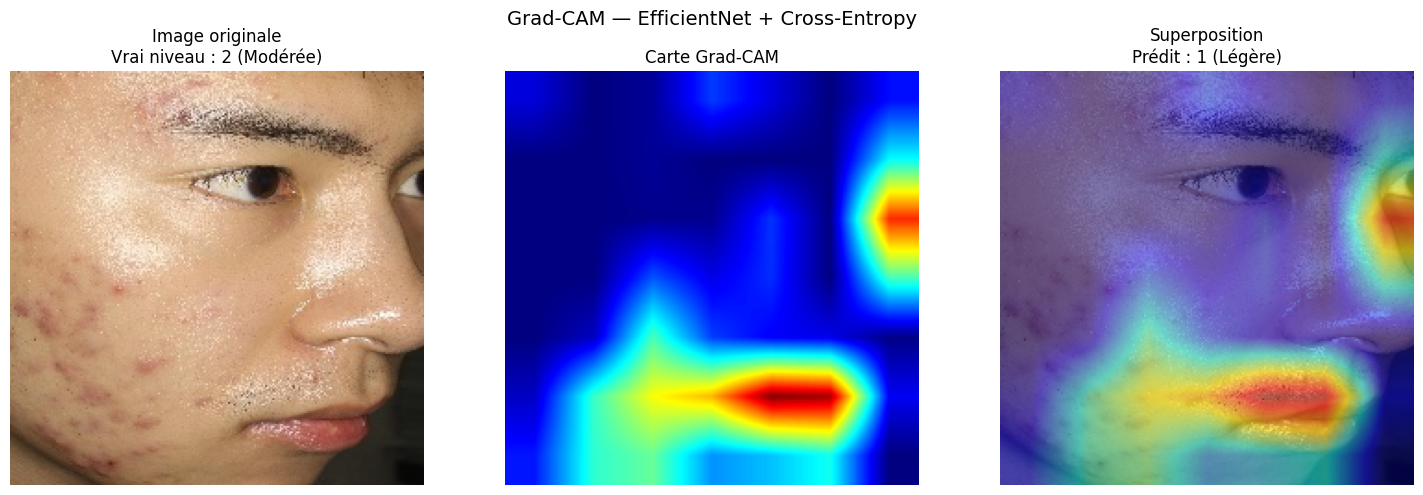

In [14]:
# Redimensionner la carte à 224x224
carte_redim = cv2.resize(carte, (224, 224))

# Convertir en couleurs (bleu→rouge)
carte_couleur = cv2.applyColorMap(
    np.uint8(255 * carte_redim), cv2.COLORMAP_JET
)
carte_couleur = cv2.cvtColor(carte_couleur, cv2.COLOR_BGR2RGB)

# Convertir l'image originale en numpy
image_np = np.array(image_pil.resize((224, 224)))

# Superposer la carte sur l'image
superposition = 0.5 * image_np + 0.5 * carte_couleur
superposition = np.uint8(superposition)

# Afficher
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_np)
axes[0].set_title("Image originale\nVrai niveau : 2 (Modérée)")
axes[0].axis("off")

axes[1].imshow(carte_couleur)
axes[1].set_title("Carte Grad-CAM")
axes[1].axis("off")

axes[2].imshow(superposition)
axes[2].set_title(f"Superposition\nPrédit : {classe_predite} ({noms[classe_predite]})")
axes[2].axis("off")

plt.suptitle("Grad-CAM — EfficientNet + Cross-Entropy", fontsize=14)
plt.tight_layout()
plt.show()

## Partie 2 — Test de biais sur peaux foncées

Le dataset ACNE04 est quasi-exclusivement composé de patients asiatiques.
On teste ici notre modèle sur 3 images de peaux foncées pour illustrer
le problème de représentation dans les données d'entraînement.

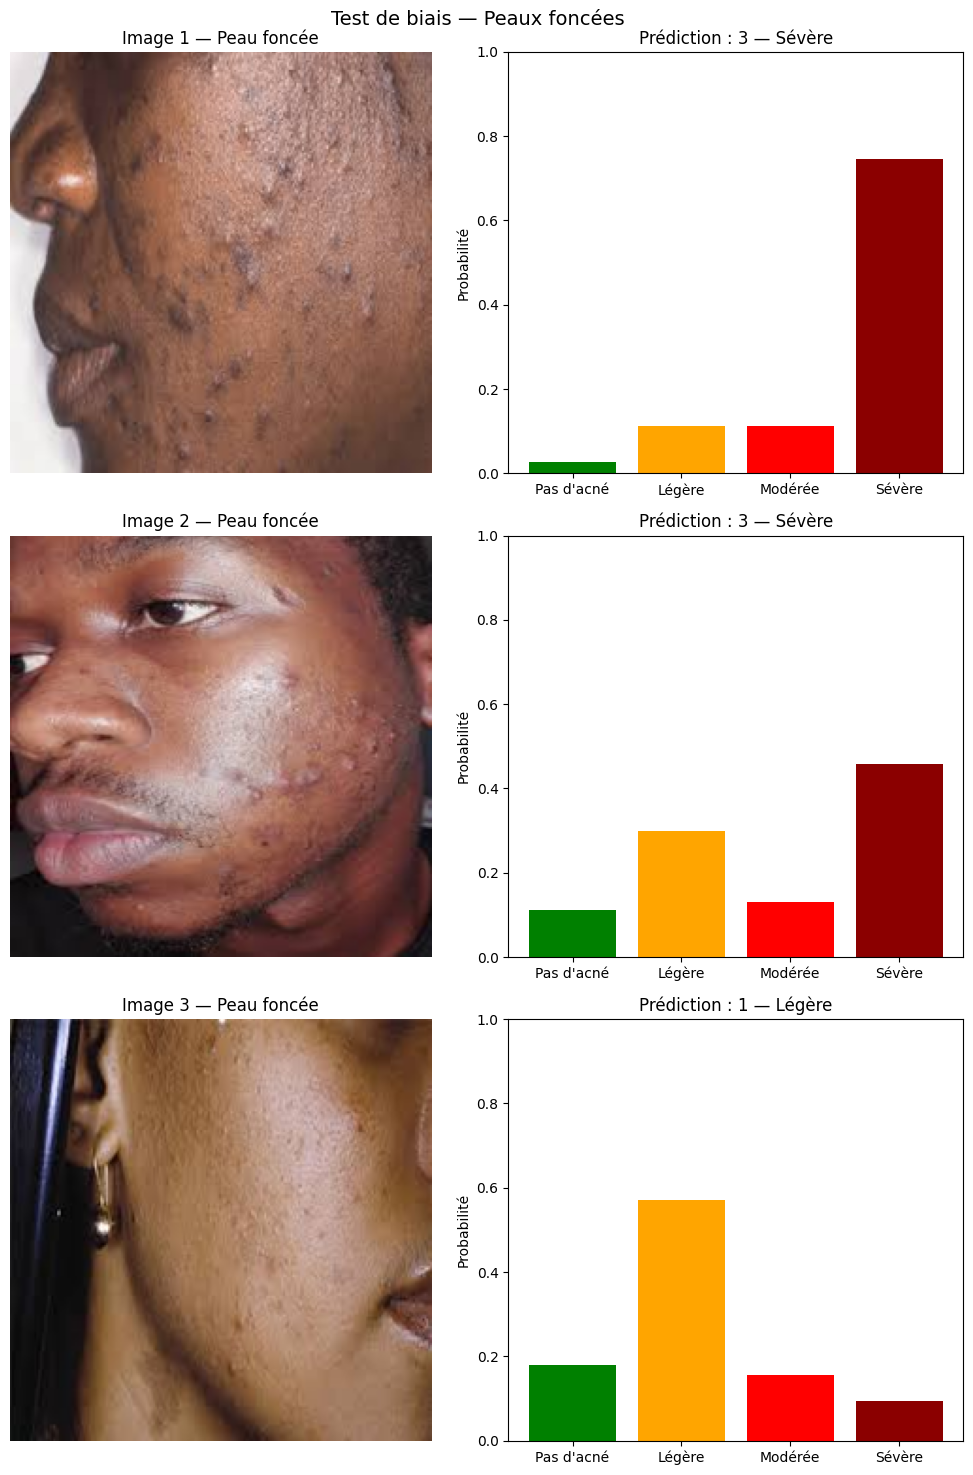

In [22]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

BIAIS_PATH = "../data/test_biais"
images_biais = os.listdir(BIAIS_PATH)
noms = {0: "Pas d'acné", 1: "Légère", 2: "Modérée", 3: "Sévère"}

fig, axes = plt.subplots(len(images_biais), 2, figsize=(10, 5 * len(images_biais)))

for idx, nom_image in enumerate(images_biais):
    chemin = os.path.join(BIAIS_PATH, nom_image)
    image_pil = Image.open(chemin).convert("RGB")
    image_tensor = transform(image_pil)

    meilleur_modele.eval()
    with torch.no_grad():
        image_input = image_tensor.unsqueeze(0).to(device)
        sorties = meilleur_modele(image_input)
        classe_predite = sorties.argmax().item()
        proba = torch.softmax(sorties, dim=1)[0]

    image_np = np.array(image_pil.resize((224, 224)))

    axes[idx][0].imshow(image_np)
    axes[idx][0].set_title(f"Image {idx+1} — Peau foncée")
    axes[idx][0].axis("off")

    axes[idx][1].bar(
        [noms[i] for i in range(4)],
        proba.cpu().numpy(),
        color=["green", "orange", "red", "darkred"]
    )
    axes[idx][1].set_title(f"Prédiction : {classe_predite} — {noms[classe_predite]}")
    axes[idx][1].set_ylim(0, 1)
    axes[idx][1].set_ylabel("Probabilité")

plt.suptitle("Test de biais — Peaux foncées", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/gradcam.png", dpi=150, bbox_inches='tight')
plt.show()